In [1]:
def unpack(xys):
    return [xy[0] for xy in xys], [xy[1] for xy in xys]

C:\Users\hekma012\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:24: RuntimeWarning: overflow encountered in exp


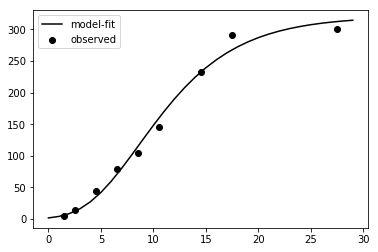

In [2]:
# reported in Corley et al, 1971
# year - trunk mass

xys = [[1.5, 4.7],
        [2.5, 13.8],
        [4.5, 43.6],
        [6.5, 78.9],
        [8.5, 103.7],
        [10.5, 145.3],
        [14.5, 232.6],
        [17.5, 290.7],
        [27.5, 300.5],]

xs = [xy[0] for xy in xys]
ys = [xy[1] for xy in xys]

import matplotlib.pyplot as plt
%matplotlib inline

from scipy.optimize import curve_fit
import numpy as np

def g(x,a,b,c):
    y = a*np.exp(-b*np.exp(-c*x))
    return y

params, _ = curve_fit(g, xs, ys)
ygs = [g(x,*params) for x in xs]

fig, ax = plt.subplots()

ax.scatter(xs,ys, color='black', label='observed')

xms = np.arange(0,30,1)
ygs = [g(x,*params) for x in xms]

ax.plot(xms,ygs, color='black', label='model-fit')

ax.legend()

dydxs = []

dx = 0.1

for x in xms:
    num = g(x+dx, *params) - g(x, *params)
    denum = dx
    dydx = num/denum
    dydxs += [dydx]

ls = [[x,round(y,1)] for x,y in zip(xms[::3], dydxs[::3])]

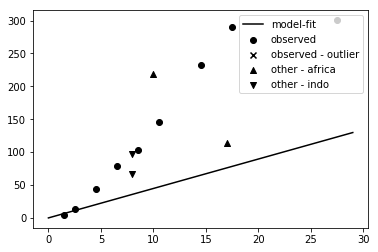

In [3]:
# reported in Corley et al, 1971
# year - root mass

xys = [[1.5, 8.8],
        [2.5, 15.9],
        [4.5, 36.4],
        [6.5, 40.6],
        [8.5, 44.0],
        [10.5, 49.0],
        [14.5, 68.9],
        [17.5, 61.6],]
      #[27.5, 130.8]]

outliers = []

c = 1000/144

other_africa = [[17, c*16.4], [10, c*31.5]]
other_indo = [[8, c*14.1], [8, c*9.7]]

import matplotlib.pyplot as plt
%matplotlib inline

from scipy.optimize import curve_fit
import numpy as np

def g(x,a,b,c):
    y = a*np.exp(-b*np.exp(-c*x))
    return y

def f(x, a):
    return a*x

opt = 'f'

if opt == 'g':
    func = g
    p0 = [93.92359701,  2.08304381,  0.11793905]
else:
    func = f
    p0 = [1]
    
params, _ = curve_fit(func, *unpack(xys), p0=p0)
yfs = [func(x,*params) for x in xs]

fig, ax = plt.subplots()

ax.scatter(xs,ys, color='black', label='observed')

ax.scatter(*unpack(outliers), color='black', marker= 'x',
           label='observed - outlier')

ax.scatter(*unpack(other_africa), color='black', marker= '^',
           label='other - africa')

ax.scatter(*unpack(other_indo), color='black', marker= 'v',
           label='other - indo')

xms = np.arange(0,30,1)
yfs = [func(x,*params) for x in xms]

ax.plot(xms,yfs, color='black', label='model-fit')

ax.legend()

dydxs = []

dx = 0.1

for x in xms:
    num = func(x+dx, *params) - func(x, *params)
    denum = dx
    dydx = num/denum
    dydxs += [dydx]

ls = [[x,round(y,1)] for x,y in zip(xms[::3], dydxs[::3])]

In [4]:
import pandas as pd
import os

In [5]:
os.listdir('../../data/agrifood')

['KBD - 2004 - weather.xlsx',
 'KBD - 2004.xlsx',
 'KBD - 2006.xlsx',
 'KBD - 2008.xlsx',
 'Weather',
 'Yield']

2006 [9.77498218 3.67657493 2.2261656 ]


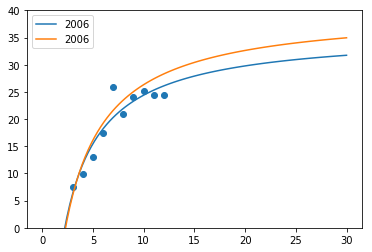

In [78]:
ddir = '../../data/agrifood'

fig, ax = plt.subplots()

fname = 'KBD - 2006.xlsx'

fpath = os.path.join(ddir, fname)

df = pd.read_excel(fpath)

s = df['ABW (kg)']

m = s.resample('Y').max()

t0 = int(fname.split('.')[0].split('-')[1].strip())
ts = [x.year - t0  for x in m.index]
ys = list(m.values)

f = lambda x, a, b, c: a*((x-c)/(1+((x-c)/b)))

params, _ = curve_fit(f, ts, ys)

print(t0, params)

tms = np.linspace(0,30,100)
ybfs = np.array([f(t,*params) for t in tms])

paramsm = [10, 4, 2.3]

yms = np.array([f(t,*paramsm) for t in tms])

ax.scatter(ts,ys)
ax.plot(tms,ybfs, label=t0)
ax.plot(tms,yms, label=t0)
ax.set_ylim(0,40)

ax.legend()

C:\Users\hekma012\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:19: RuntimeWarning: overflow encountered in exp


(0, 1)

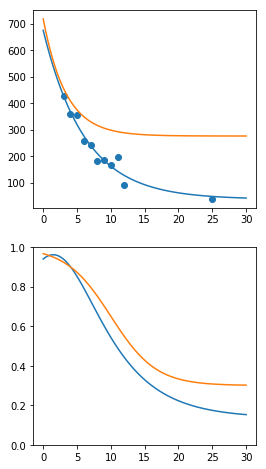

In [75]:
ddir = '../../data/agrifood'

fig, (ax, ax2) = plt.subplots(2,1, figsize=(4,8))

fname = 'KBD - 2006.xlsx'

fpath = os.path.join(ddir, fname)

df = pd.read_excel(fpath)

s = df['BC (1/ha/mo)']

a, b, c = 23, 1.6, .3

def f(t, a, b, c):
    return (144/12)*a*(1+b*np.exp(-c*(t)))

def g(t, a, b, c):
    return (144/12)*a*(1+b*np.exp(-c*(t)))

m = s.resample('Y').max()

t0 = int(fname.split('.')[0].split('-')[1].strip())
ts = [x.year - t0  for x in m.index]
ys = list(m.values)

params, _ = curve_fit(g, ts, ys)

ts.append(25)
ys.append(40)

tms = np.linspace(0,30,100)
yms = np.array([g(t,*params) for t in tms])

tms = np.linspace(0,30,100)
yfs = np.array([f(t,a,b,c) for t in tms])

ax.scatter(ts,ys)
ax.plot(tms,yms, label=t0)
ax.plot(tms,yfs, label=t0)

yffs = yms/yfs

def sigmoid(t, k, t0, v1):
    return (1-v1)*1/(1 + np.exp(k*(t-t0))) + v1

k = 0.3
t0 = 10
v1 = 0.3

yfffs = np.array([sigmoid(t, k, t0, v1) for t in tms])

ax2.plot(tms, yffs)
ax2.plot(tms, yfffs)
ax2.set_ylim(0, 1)